# JiT Like Latent Space Generative Model

* Demontrates how a HBQ quantized autoencoder makes a great framework for JiT style vision models

In [1]:
# https://chatgpt.com/share/6a67d96f-654c-83e8-b247-635106fce598
 
import numpy as np
# import os
# import time
from pathlib import Path
# import torch
# import torch.backends.cudnn as cudnn
# import torchvision.transforms as transforms
# import torchvision.datasets as datasets
import copy
# from torchvision.transforms import v2
import IPython.display as ipd
# from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import hierarchical_binary_quantization.hbq as hbq
import hierarchical_binary_quantization.misc.checkpoint_helpers as ch
import hierarchical_binary_quantization.misc.image_helpers as ih
import hierarchical_binary_quantization.misc.ema_helper as eh
import hierarchical_binary_quantization.misc.dataset_helpers as dh
#import hierarchical_binary_quantization.example_autoencoder as eae
import hierarchical_binary_quantization.example_narrow_reciptive_field_autoencoder as enrfa


## Load a pretrained HBQ quantized autoencoder

In [2]:
autoencoder_cp = 'checkpoints/good/reallygood_LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth'
autoencoder = ch.create_from_checkpoint(enrfa.LocalQuantizingAutoencoder,autoencoder_cp)
autoencoder.cpu()
autoencoder.eval()
autoencoder.config

🔄 Loading checkpoint from checkpoints/good/reallygood_LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth with {'in_channels': 3, 'stem_dim': 64, 'stem_blocks': 1, 'patch_size': 8, 'body_dim': 256, 'body': ('res', 'attn', 'res'), 'attn_block': 4, 'attn_halo': 1, 'attn_heads': 4, 'attn_rope_base': 150, 'latent_dim': 32, 'quant_dim': 16, 'n_rounds': 4, 'refine_blocks': 2, 'depatchify_overlap': 1, 'use_mae_aux': True, 'mae_mask_ratio': 0.5, 'mae_heads': 2, 'mae_depth': 2}


LocalAutoencoderConfig(in_channels=3, stem_dim=64, stem_blocks=1, patch_size=8, body_dim=256, body=('res', 'attn', 'res'), attn_block=4, attn_halo=1, attn_heads=4, attn_rope_base=150, latent_dim=32, quant_dim=16, n_rounds=4, refine_blocks=2, depatchify_overlap=1, use_mae_aux=True, mae_mask_ratio=0.5, mae_heads=2, mae_depth=2)

## Load an interesting precomputed Latent Space Dataset

Example Quantized Latent data:
tensor([[12, 12, 11,  ..., 12, 12, 12],
        [12, 12, 11,  ..., 12, 12, 12],
        [12, 12, 11,  ..., 12, 12, 12],
        ...,
        [10, 12, 11,  ..., 14, 11, 12],
        [11, 13, 11,  ..., 14, 11, 12],
        [10, 13, 11,  ..., 14, 11, 12]], dtype=torch.int8) of shape torch.Size([16, 32, 32])
decodes to:


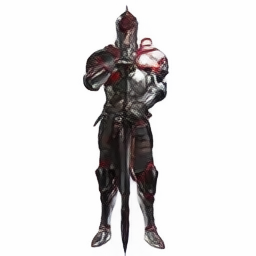

In [3]:
dataset_name='fantasy'
def get_latent_dataset_and_dataloader(dataset_name,width=256,height=256,batch_size=8, shuffle=False):
    dataset_path = f"data/dbs/quantized_latents_for_{dataset_name}_{width}x{height}.sqlite3"
    bds = dh.BlobDataset(dataset_path)
    if debugprint_example_element := True:
        example_element = dh.bytes_to_tensor(bds[0][1])
        print(f"Example Quantized Latent data:\n{example_element[0]} of shape {example_element.shape}")
    lds = dh.QuantizedLatentDataset(bds)
    ldl = DataLoader(lds,shuffle=shuffle,batch_size=batch_size)
    return lds,ldl

def smoke_test_data_loader_and_autoencoder(dataset):
    lds,ldl = get_latent_dataset_and_dataloader(dataset,shuffle=True)
    id_batch, ld_batch, metadata_batch = next(iter(ldl))
    print("decodes to:")
    ipd.display(ih.tensor_to_pil(autoencoder.decode(autoencoder.post_quant(ld_batch))[0]))

smoke_test_data_loader_and_autoencoder(dataset='fantasy')


## Latent JiT

In [4]:
# model_uitl
from math import pi
import torch
from torch import nn
import numpy as np
from einops import rearrange, repeat


def broadcat(tensors, dim = -1):
    num_tensors = len(tensors)
    shape_lens = set(list(map(lambda t: len(t.shape), tensors)))
    assert len(shape_lens) == 1, 'tensors must all have the same number of dimensions'
    shape_len = list(shape_lens)[0]
    dim = (dim + shape_len) if dim < 0 else dim
    dims = list(zip(*map(lambda t: list(t.shape), tensors)))
    expandable_dims = [(i, val) for i, val in enumerate(dims) if i != dim]
    assert all([*map(lambda t: len(set(t[1])) <= 2, expandable_dims)]), 'invalid dimensions for broadcastable concatentation'
    max_dims = list(map(lambda t: (t[0], max(t[1])), expandable_dims))
    expanded_dims = list(map(lambda t: (t[0], (t[1],) * num_tensors), max_dims))
    expanded_dims.insert(dim, (dim, dims[dim]))
    expandable_shapes = list(zip(*map(lambda t: t[1], expanded_dims)))
    tensors = list(map(lambda t: t[0].expand(*t[1]), zip(tensors, expandable_shapes)))
    return torch.cat(tensors, dim = dim)

def rotate_half(x):
    x = rearrange(x, '... (d r) -> ... d r', r = 2)
    x1, x2 = x.unbind(dim = -1)
    x = torch.stack((-x2, x1), dim = -1)
    return rearrange(x, '... d r -> ... (d r)')

class VisionRotaryEmbedding(nn.Module):
    def __init__(
        self,
        dim,
        pt_seq_len,
        ft_seq_len=None,
        custom_freqs = None,
        freqs_for = 'lang',
        theta = 10000,
        max_freq = 10,
        num_freqs = 1,
    ):
        super().__init__()
        if custom_freqs:
            freqs = custom_freqs
        elif freqs_for == 'lang':
            freqs = 1. / (theta ** (torch.arange(0, dim, 2)[:(dim // 2)].float() / dim))
        elif freqs_for == 'pixel':
            freqs = torch.linspace(1., max_freq / 2, dim // 2) * pi
        elif freqs_for == 'constant':
            freqs = torch.ones(num_freqs).float()
        else:
            raise ValueError(f'unknown modality {freqs_for}')

        if ft_seq_len is None: ft_seq_len = pt_seq_len
        t = torch.arange(ft_seq_len) / ft_seq_len * pt_seq_len

        freqs_h = torch.einsum('..., f -> ... f', t, freqs)
        freqs_h = repeat(freqs_h, '... n -> ... (n r)', r = 2)

        freqs_w = torch.einsum('..., f -> ... f', t, freqs)
        freqs_w = repeat(freqs_w, '... n -> ... (n r)', r = 2)

        freqs = broadcat((freqs_h[:, None, :], freqs_w[None, :, :]), dim = -1)

        self.register_buffer("freqs_cos", freqs.cos())
        self.register_buffer("freqs_sin", freqs.sin())

    def forward(self, t, start_index = 0):
        rot_dim = self.freqs_cos.shape[-1]
        end_index = start_index + rot_dim
        assert rot_dim <= t.shape[-1], f'feature dimension {t.shape[-1]} is not of sufficient size to rotate in all the positions {rot_dim}'
        t_left, t, t_right = t[..., :start_index], t[..., start_index:end_index], t[..., end_index:]
        t = (t * self.freqs_cos) + (rotate_half(t) * self.freqs_sin)
        return torch.cat((t_left, t, t_right), dim = -1)


class VisionRotaryEmbeddingFast(nn.Module):
    def __init__(
        self,
        dim,
        pt_seq_len=16,
        ft_seq_len=None,
        custom_freqs = None,
        freqs_for = 'lang',
        theta = 10000,
        max_freq = 10,
        num_freqs = 1,
        num_cls_token = 0
    ):
        super().__init__()
        if custom_freqs:
            freqs = custom_freqs
        elif freqs_for == 'lang':
            freqs = 1. / (theta ** (torch.arange(0, dim, 2)[:(dim // 2)].float() / dim))
        elif freqs_for == 'pixel':
            freqs = torch.linspace(1., max_freq / 2, dim // 2) * pi
        elif freqs_for == 'constant':
            freqs = torch.ones(num_freqs).float()
        else:
            raise ValueError(f'unknown modality {freqs_for}')

        if ft_seq_len is None: ft_seq_len = pt_seq_len
        t = torch.arange(ft_seq_len) / ft_seq_len * pt_seq_len

        freqs = torch.einsum('..., f -> ... f', t, freqs)
        freqs = repeat(freqs, '... n -> ... (n r)', r = 2)
        freqs = broadcat((freqs[:, None, :], freqs[None, :, :]), dim = -1)

        if num_cls_token > 0:
            freqs_flat = freqs.view(-1, freqs.shape[-1])  # [N_img, D]
            cos_img = freqs_flat.cos()
            sin_img = freqs_flat.sin()

            # prepend in-context cls token
            N_img, D = cos_img.shape
            cos_pad = torch.ones(num_cls_token, D, dtype=cos_img.dtype, device=cos_img.device)
            sin_pad = torch.zeros(num_cls_token, D, dtype=sin_img.dtype, device=sin_img.device)

            self.freqs_cos = torch.cat([cos_pad, cos_img], dim=0).cuda()  # [N_cls+N_img, D]
            self.freqs_sin = torch.cat([sin_pad, sin_img], dim=0).cuda()
        else:
            self.freqs_cos = freqs.cos().view(-1, freqs.shape[-1]).cuda()
            self.freqs_sin = freqs.sin().view(-1, freqs.shape[-1]).cuda()

    def forward(self, t): return  t * self.freqs_cos + rotate_half(t) * self.freqs_sin


class RMSNorm(nn.Module):
    def __init__(self, hidden_size, eps=1e-6):
        """
        LlamaRMSNorm is equivalent to T5LayerNorm
        """
        super().__init__()
        self.weight = nn.Parameter(torch.ones(hidden_size))
        self.variance_epsilon = eps

    def forward(self, hidden_states):
        input_dtype = hidden_states.dtype
        hidden_states = hidden_states.to(torch.float32)
        variance = hidden_states.pow(2).mean(-1, keepdim=True)
        hidden_states = hidden_states * torch.rsqrt(variance + self.variance_epsilon)
        return (self.weight * hidden_states).to(input_dtype)


def get_2d_sincos_pos_embed(embed_dim, grid_size, cls_token=False, extra_tokens=0):
    """
    grid_size: int of the grid height and width
    return:
    pos_embed: [grid_size*grid_size, embed_dim] or [1+grid_size*grid_size, embed_dim] (w/ or w/o cls_token)
    """
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)  # here w goes first
    grid = np.stack(grid, axis=0)

    grid = grid.reshape([2, 1, grid_size, grid_size])
    pos_embed = get_2d_sincos_pos_embed_from_grid(embed_dim, grid)
    if cls_token and extra_tokens > 0:
        pos_embed = np.concatenate([np.zeros([extra_tokens, embed_dim]), pos_embed], axis=0)
    return pos_embed


def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):
    assert embed_dim % 2 == 0

    # use half of dimensions to encode grid_h
    emb_h = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[0])  # (H*W, D/2)
    emb_w = get_1d_sincos_pos_embed_from_grid(embed_dim // 2, grid[1])  # (H*W, D/2)

    emb = np.concatenate([emb_h, emb_w], axis=1) # (H*W, D)
    return emb


def get_1d_sincos_pos_embed_from_grid(embed_dim, pos):
    """
    embed_dim: output dimension for each position
    pos: a list of positions to be encoded: size (M,)
    out: (M, D)
    """
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float64)
    omega /= embed_dim / 2.
    omega = 1. / 10000**omega  # (D/2,)

    pos = pos.reshape(-1)  # (M,)
    out = np.einsum('m,d->md', pos, omega)  # (M, D/2), outer product

    emb_sin = np.sin(out) # (M, D/2)
    emb_cos = np.cos(out) # (M, D/2)

    emb = np.concatenate([emb_sin, emb_cos], axis=1)  # (M, D)
    return emb

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

#from model_jit import JiTBlock, FinalLayer, TimestepEmbedder, LabelEmbedder
#from util.model_util import get_2d_sincos_pos_embed, VisionRotaryEmbeddingFast
import math
def modulate(x, shift, scale):
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)
class SwiGLUFFN(nn.Module):
    def __init__(
        self,
        dim: int,
        hidden_dim: int,
        drop=0.0,
        bias=True
    ) -> None:
        super().__init__()
        hidden_dim = int(hidden_dim * 2 / 3)
        self.w12 = nn.Linear(dim, 2 * hidden_dim, bias=bias)
        self.w3 = nn.Linear(hidden_dim, dim, bias=bias)
        self.ffn_dropout = nn.Dropout(drop)

    def forward(self, x):
        x12 = self.w12(x)
        x1, x2 = x12.chunk(2, dim=-1)
        hidden = F.silu(x1) * x2
        return self.w3(self.ffn_dropout(hidden))


class TimestepEmbedder(nn.Module):
    """
    Embeds scalar timesteps into vector representations.
    """
    def __init__(self, hidden_size, frequency_embedding_size=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(frequency_embedding_size, hidden_size, bias=True),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size, bias=True),
        )
        self.frequency_embedding_size = frequency_embedding_size

    @staticmethod
    def timestep_embedding(t, dim, max_period=10000):
        """
        Create sinusoidal timestep embeddings.
        :param t: a 1-D Tensor of N indices, one per batch element.
                          These may be fractional.
        :param dim: the dimension of the output.
        :param max_period: controls the minimum frequency of the embeddings.
        :return: an (N, D) Tensor of positional embeddings.
        """
        # https://github.com/openai/glide-text2im/blob/main/glide_text2im/nn.py
        half = dim // 2
        freqs = torch.exp(
            -math.log(max_period) * torch.arange(start=0, end=half, dtype=torch.float32) / half
        ).to(device=t.device)
        args = t[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
        return embedding

    def forward(self, t):
        t_freq = self.timestep_embedding(t, self.frequency_embedding_size)
        t_emb = self.mlp(t_freq)
        return t_emb

def scaled_dot_product_attention(query, key, value, dropout_p=0.0) -> torch.Tensor:
    L, S = query.size(-2), key.size(-2)
    scale_factor = 1 / math.sqrt(query.size(-1))
    attn_bias = torch.zeros(query.size(0), 1, L, S, dtype=query.dtype).cuda()

    with torch.cuda.amp.autocast(enabled=False):
        attn_weight = query.float() @ key.float().transpose(-2, -1) * scale_factor
    attn_weight += attn_bias
    attn_weight = torch.softmax(attn_weight, dim=-1)
    attn_weight = torch.dropout(attn_weight, dropout_p, train=True)
    return attn_weight @ value


class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=True, qk_norm=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads

        self.q_norm = RMSNorm(head_dim) if qk_norm else nn.Identity()
        self.k_norm = RMSNorm(head_dim) if qk_norm else nn.Identity()

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, rope):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]   # make torchscript happy (cannot use tensor as tuple)

        q = self.q_norm(q)
        k = self.k_norm(k)

        q = rope(q)
        k = rope(k)

        x = scaled_dot_product_attention(q, k, v, dropout_p=self.attn_drop.p if self.training else 0.)

        x = x.transpose(1, 2).reshape(B, N, C)

        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class LabelEmbedder(nn.Module):
    """
    Embeds class labels into vector representations. Also handles label dropout for classifier-free guidance.
    """
    def __init__(self, num_classes, hidden_size):
        super().__init__()
        self.embedding_table = nn.Embedding(num_classes + 1, hidden_size)
        self.num_classes = num_classes

    def forward(self, labels):
        embeddings = self.embedding_table(labels)
        return embeddings

class FinalLayer(nn.Module):
    """
    The final layer of JiT.
    """
    def __init__(self, hidden_size, patch_size, out_channels):
        super().__init__()
        self.norm_final = RMSNorm(hidden_size)
        self.linear = nn.Linear(hidden_size, patch_size * patch_size * out_channels, bias=True)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 2 * hidden_size, bias=True)
        )

    @torch.compile
    def forward(self, x, c):
        shift, scale = self.adaLN_modulation(c).chunk(2, dim=1)
        x = modulate(self.norm_final(x), shift, scale)
        x = self.linear(x)
        return x


class JiTBlock(nn.Module):
    def __init__(self, hidden_size, num_heads, mlp_ratio=4.0, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.norm1 = RMSNorm(hidden_size, eps=1e-6)
        self.attn = Attention(hidden_size, num_heads=num_heads, qkv_bias=True, qk_norm=True,
                              attn_drop=attn_drop, proj_drop=proj_drop)
        self.norm2 = RMSNorm(hidden_size, eps=1e-6)
        mlp_hidden_dim = int(hidden_size * mlp_ratio)
        self.mlp = SwiGLUFFN(hidden_size, mlp_hidden_dim, drop=proj_drop)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 6 * hidden_size, bias=True)
        )

    @torch.compile
    def forward(self, x,  c, feat_rope=None):
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = self.adaLN_modulation(c).chunk(6, dim=-1)
        x = x + gate_msa.unsqueeze(1) * self.attn(modulate(self.norm1(x), shift_msa, scale_msa), rope=feat_rope)
        x = x + gate_mlp.unsqueeze(1) * self.mlp(modulate(self.norm2(x), shift_mlp, scale_mlp))
        return x


class LatentJiT(nn.Module):
    """
    JiT backbone adapted to run directly on an HxW grid of continuous latent
    vectors instead of patchified pixels. No BottleneckPatchEmbed, no
    unpatchify -- one grid cell in, one grid cell out.
    """
    def __init__(
        self,
        grid_size=32,
        latent_dim=8,
        hidden_size=384,
        depth=6,
        num_heads=6,
        mlp_ratio=4.0,
        attn_drop=0.0,
        proj_drop=0.0,
        num_classes=1,
    ):
        super().__init__()
        self.grid_size = grid_size
        self.latent_dim = latent_dim
        self.hidden_size = hidden_size
        self.num_classes = num_classes

        self.t_embedder = TimestepEmbedder(hidden_size)
        self.y_embedder = LabelEmbedder(num_classes, hidden_size)

        # replaces BottleneckPatchEmbed -- one linear per grid cell, no pixels involved
        self.x_embedder = nn.Linear(latent_dim, hidden_size)

        num_tokens = grid_size * grid_size
        self.pos_embed = nn.Parameter(torch.zeros(1, num_tokens, hidden_size), requires_grad=False)

        # NOTE: pt_seq_len is the LATENT grid size (32), not input_size // patch_size --
        # there's no patchify step here, so that JiT formula doesn't apply.
        half_head_dim = hidden_size // num_heads // 2
        self.feat_rope = VisionRotaryEmbeddingFast(
            dim=half_head_dim, pt_seq_len=grid_size, num_cls_token=0
        )

        self.blocks = nn.ModuleList([
            JiTBlock(hidden_size, num_heads, mlp_ratio=mlp_ratio,
                     attn_drop=attn_drop, proj_drop=proj_drop)
            for _ in range(depth)
        ])

        # patch_size=1: FinalLayer's "patch" is just one grid cell, latent_dim channels
        self.final_layer = FinalLayer(hidden_size, patch_size=1, out_channels=latent_dim)

        self.initialize_weights()

    def initialize_weights(self):
        def _basic_init(m):
            if isinstance(m, nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
        self.apply(_basic_init)

        pos_embed = get_2d_sincos_pos_embed(self.pos_embed.shape[-1], self.grid_size)
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))

        nn.init.normal_(self.y_embedder.embedding_table.weight, std=0.02)
        nn.init.normal_(self.t_embedder.mlp[0].weight, std=0.02)
        nn.init.normal_(self.t_embedder.mlp[2].weight, std=0.02)

        for block in self.blocks:
            nn.init.constant_(block.adaLN_modulation[-1].weight, 0)
            nn.init.constant_(block.adaLN_modulation[-1].bias, 0)
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].weight, 0)
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].bias, 0)
        nn.init.constant_(self.final_layer.linear.weight, 0)
        nn.init.constant_(self.final_layer.linear.bias, 0)

    def forward(self, x, t, y):
        """
        x: (N, latent_dim, H, W)  -- e.g. (N, 8, 32, 32)
        t: (N,)
        y: (N,)
        """
        B, C, H, W = x.shape
        assert H == self.grid_size and W == self.grid_size

        c = self.t_embedder(t) + self.y_embedder(y)

        tokens = x.flatten(2).transpose(1, 2)      # (N, H*W, C)
        tokens = self.x_embedder(tokens)            # (N, H*W, hidden_size)
        tokens = tokens + self.pos_embed

        for block in self.blocks:
            tokens = block(tokens, c, self.feat_rope)

        tokens = self.final_layer(tokens, c)         # (N, H*W, latent_dim)
        out = tokens.transpose(1, 2).reshape(B, C, H, W)
        return out

def LatentJiT_small(**kwargs):
    return LatentJiT(hidden_size=384, depth=6, num_heads=6, latent_dim=16, **kwargs)

def LatentJiT_base(**kwargs):
    return LatentJiT(hidden_size=768, depth=12, num_heads=12, latent_dim=16, **kwargs)

In [6]:
lds,ldl = get_latent_dataset_and_dataloader('fantasy',shuffle=True)

Example Quantized Latent data:
tensor([[12, 12, 11,  ..., 12, 12, 12],
        [12, 12, 11,  ..., 12, 12, 12],
        [12, 12, 11,  ..., 12, 12, 12],
        ...,
        [10, 12, 11,  ..., 14, 11, 12],
        [11, 13, 11,  ..., 14, 11, 12],
        [10, 13, 11,  ..., 14, 11, 12]], dtype=torch.int8) of shape torch.Size([16, 32, 32])


In [7]:
if smoke_test := True:
    BS = 3
    lds,ldl = get_latent_dataset_and_dataloader('fantasy',shuffle=True, batch_size=BS)
    id_batch, ld_batch, md_batch = next(iter(ldl))
    ld_batch.shape
    device='cuda'
    lj = LatentJiT_small().to(device)
    x = torch.randn(BS, 16, 32,32).to(device)
    t = torch.zeros(BS, dtype=torch.long).to(device)
    labels = torch.zeros(BS, dtype=torch.long).to(device)
    print(x.shape, lj.forward(x,t,labels).shape)

Example Quantized Latent data:
tensor([[12, 12, 11,  ..., 12, 12, 12],
        [12, 12, 11,  ..., 12, 12, 12],
        [12, 12, 11,  ..., 12, 12, 12],
        ...,
        [10, 12, 11,  ..., 14, 11, 12],
        [11, 13, 11,  ..., 14, 11, 12],
        [10, 13, 11,  ..., 14, 11, 12]], dtype=torch.int8) of shape torch.Size([16, 32, 32])
torch.Size([3, 16, 32, 32]) torch.Size([3, 16, 32, 32])


In [ ]:
import torch
from torch.profiler import profile, ProfilerActivity

def profile_net(net, name, batch_size=8, device="cuda"):
    net = net.to(device).eval()
    x = torch.randn(batch_size, 16, 32, 32, device=device)
    t = torch.rand(batch_size, device=device)
    y = torch.zeros(batch_size, dtype=torch.long, device=device)

    for _ in range(3):
        net(x, t, y)
    torch.cuda.synchronize()

    with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as prof:
        for _ in range(10):
            net(x, t, y)
        torch.cuda.synchronize()

    print(f"\n=== {name} ===")
    print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=15))
    return prof

#prof_minimal = profile_net(MinimalSpatialViT(grid_size=32, latent_dim=8, d_model=384, num_heads=6, depth=6), "MinimalSpatialViT")
compiled = torch.compile(LatentJiT_small(grid_size=32))
prof_jit     = profile_net(compiled, "LatentJiT_small")
print(prof_jit)


E0913 16:56:36.259000 900988 torch/_subclasses/fake_tensor.py:3090] [2/0] failed while attempting to run meta for aten.mm.default
E0913 16:56:36.259000 900988 torch/_subclasses/fake_tensor.py:3090] [2/0] Traceback (most recent call last):
E0913 16:56:36.259000 900988 torch/_subclasses/fake_tensor.py:3090] [2/0]   File "/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/torch/_subclasses/fake_tensor.py", line 3086, in _dispatch_impl
E0913 16:56:36.259000 900988 torch/_subclasses/fake_tensor.py:3090] [2/0]     r = func(*args, **kwargs)
E0913 16:56:36.259000 900988 torch/_subclasses/fake_tensor.py:3090] [2/0]         ^^^^^^^^^^^^^^^^^^^^^
E0913 16:56:36.259000 900988 torch/_subclasses/fake_tensor.py:3090] [2/0]   File "/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/torch/_ops.py", line 875, in __call__
E0913 16:56:36.259000 900988 torch/_subclasses/fake_tensor.py:3090] [2/0]     return self._op(*args, **kwargs)
E0913 16:5

TorchRuntimeError: RuntimeError when making fake tensor call
  Explanation: Dynamo failed to run FX node with fake tensors: call_function <built-in function linear>(*(FakeTensor(..., device='cuda:0', size=(8, 1024, 8)), Parameter(FakeTensor(..., device='cuda:0', size=(384, 16), requires_grad=True)), Parameter(FakeTensor(..., device='cuda:0', size=(384,), requires_grad=True))), **{}): got RuntimeError('a and b must have same reduction dim, but got [8192, 8] X [16, 384].')
  Hint: Your code may result in an error when running in eager. Please double check that your code doesn't contain a similar error when actually running eager/uncompiled. You can do this by removing the `torch.compile` call, or by using `torch.compiler.set_stance("force_eager")`. 

  Developer debug context: 

 For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb4315.html

from user code:
   File "/tmp/ipykernel_900988/817344459.py", line 258, in forward
 

In [ ]:
import torch
import torch.nn as nn
#from model_jit import JiT_models


class Denoiser(nn.Module):
    def __init__(
        self,
        args
    ):
        super().__init__()
        # Pixel:
        # self.net = JiT_models[args.model](
        #     input_size=args.img_size,
        #     in_channels=3,
        #     num_classes=args.class_num,
        #     attn_drop=args.attn_dropout,
        #     proj_drop=args.proj_dropout,
        # )
        self.net = LatentJiT_small(grid_size=32, latent_dim=8, num_classes=1)

        self.img_size = args.img_size
        self.num_classes = args.class_num

        self.label_drop_prob = args.label_drop_prob
        self.P_mean = args.P_mean
        self.P_std = args.P_std
        self.t_eps = args.t_eps
        self.noise_scale = args.noise_scale

        # ema
        self.ema_decay1 = args.ema_decay1
        self.ema_decay2 = args.ema_decay2
        self.ema_params1 = None
        self.ema_params2 = None

        # generation hyper params
        self.method = args.sampling_method
        self.steps = args.num_sampling_steps
        self.cfg_scale = args.cfg
        self.cfg_interval = (args.interval_min, args.interval_max)

    def drop_labels(self, labels):
        drop = torch.rand(labels.shape[0], device=labels.device) < self.label_drop_prob
        out = torch.where(drop, torch.full_like(labels, self.num_classes), labels)
        return out

    def sample_t(self, n: int, device=None):
        z = torch.randn(n, device=device) * self.P_std + self.P_mean
        return torch.sigmoid(z)

    def forward(self, x, labels):
        labels_dropped = self.drop_labels(labels) if self.training else labels

        t = self.sample_t(x.size(0), device=x.device).view(-1, *([1] * (x.ndim - 1)))
        e = torch.randn_like(x) * self.noise_scale

        z = t * x + (1 - t) * e
        v = (x - z) / (1 - t).clamp_min(self.t_eps)

        x_pred = self.net(z, t.flatten(), labels_dropped)
        v_pred = (x_pred - z) / (1 - t).clamp_min(self.t_eps)

        # l2 loss
        loss = (v - v_pred) ** 2
        loss = loss.mean(dim=(1, 2, 3)).mean()

        return loss

    @torch.no_grad()
    def generate(self, labels):
        device = labels.device
        bsz = labels.size(0)
        z = self.noise_scale * torch.randn(bsz, 3, self.img_size, self.img_size, device=device)
        timesteps = torch.linspace(0.0, 1.0, self.steps+1, device=device).view(-1, *([1] * z.ndim)).expand(-1, bsz, -1, -1, -1)

        if self.method == "euler":
            stepper = self._euler_step
        elif self.method == "heun":
            stepper = self._heun_step
        else:
            raise NotImplementedError

        # ode
        for i in range(self.steps - 1):
            t = timesteps[i]
            t_next = timesteps[i + 1]
            z = stepper(z, t, t_next, labels)
        # last step euler
        z = self._euler_step(z, timesteps[-2], timesteps[-1], labels)
        return z

    @torch.no_grad()
    def _forward_sample(self, z, t, labels):
        # conditional
        x_cond = self.net(z, t.flatten(), labels)
        v_cond = (x_cond - z) / (1.0 - t).clamp_min(self.t_eps)

        # unconditional
        x_uncond = self.net(z, t.flatten(), torch.full_like(labels, self.num_classes))
        v_uncond = (x_uncond - z) / (1.0 - t).clamp_min(self.t_eps)

        # cfg interval
        low, high = self.cfg_interval
        interval_mask = (t < high) & ((low == 0) | (t > low))
        cfg_scale_interval = torch.where(interval_mask, self.cfg_scale, 1.0)

        return v_uncond + cfg_scale_interval * (v_cond - v_uncond)

    @torch.no_grad()
    def _euler_step(self, z, t, t_next, labels):
        v_pred = self._forward_sample(z, t, labels)
        z_next = z + (t_next - t) * v_pred
        return z_next

    @torch.no_grad()
    def _heun_step(self, z, t, t_next, labels):
        v_pred_t = self._forward_sample(z, t, labels)

        z_next_euler = z + (t_next - t) * v_pred_t
        v_pred_t_next = self._forward_sample(z_next_euler, t_next, labels)

        v_pred = 0.5 * (v_pred_t + v_pred_t_next)
        z_next = z + (t_next - t) * v_pred
        return z_next

    @torch.no_grad()
    def update_ema(self):
        source_params = list(self.parameters())
        for targ, src in zip(self.ema_params1, source_params):
            targ.detach().mul_(self.ema_decay1).add_(src, alpha=1 - self.ema_decay1)
        for targ, src in zip(self.ema_params2, source_params):
            targ.detach().mul_(self.ema_decay2).add_(src, alpha=1 - self.ema_decay2)


In [ ]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [ ]:
# PIXEL
# ds_path = "../../edm_diffusion_vibe_coding/data/256x256/fantasy"
# transform_train = transforms.Compose([
#         transforms.Lambda(lambda img: center_crop_arr(img, 256)),
#         transforms.ToTensor(),
#         transforms.Resize((256,256)),
#         transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
# ])
# dataset_train = datasets.ImageFolder(ds_path, transform=transform_train)
# data_loader_train = torch.utils.data.DataLoader(dataset_train, batch_size=8)
data_loader_train = DataLoader(lds, batch_size=BS)
ids,imgs,labels = next(iter(data_loader_train))
clss = torch.zeros(BS, dtype=torch.long)
imgs.shape


torch.Size([3, 16, 32, 32])

In [ ]:

from dataclasses import dataclass

@dataclass
class Args:
    model='latent_JiT-B/16'
    img_size=32
    class_num=1
    attn_dropout=0.05
    proj_dropout=0.05
    label_drop_prob=0.05
    P_mean=-0.8
    P_std=0.8
    t_eps=5e-2
    noise_scale=1
    ema_decay1=0.9999
    ema_decay2=0.99
    sampling_method="heun"
    num_sampling_steps=50
    cfg=1
    interval_min=0
    interval_max=0
    # not decode
    gen_bsz=3
    num_images=3
    output_dir="outputs"


In [ ]:
class LatentDenoiser(Denoiser):
    def __init__(self, args, net):
        nn.Module.__init__(self)  # skip Denoiser.__init__'s img-shaped net construction
        self.net = net
        self.latent_dim = net.latent_dim
        self.grid_size = net.grid_size

        self.num_classes = args.class_num
        self.label_drop_prob = args.label_drop_prob
        self.P_mean = args.P_mean
        self.P_std = args.P_std
        self.t_eps = args.t_eps
        self.noise_scale = args.noise_scale

        self.ema_decay1 = args.ema_decay1
        self.ema_decay2 = args.ema_decay2
        self.ema_params1 = None
        self.ema_params2 = None

        self.method = args.sampling_method
        self.steps = args.num_sampling_steps
        self.cfg_scale = args.cfg
        self.cfg_interval = (args.interval_min, args.interval_max)

    @torch.no_grad()
    def generate(self, labels):
        device = labels.device
        bsz = labels.size(0)
        # only real change from Denoiser.generate(): correct shape, not (3, img_size, img_size)
        z = self.noise_scale * torch.randn(
            bsz, self.latent_dim, self.grid_size, self.grid_size, device=device
        )
        timesteps = torch.linspace(0.0, 1.0, self.steps + 1, device=device).view(
            -1, *([1] * z.ndim)
        ).expand(-1, bsz, -1, -1, -1)

        stepper = self._euler_step if self.method == "euler" else self._heun_step
        for i in range(self.steps - 1):
            z = stepper(z, timesteps[i], timesteps[i + 1], labels)
        z = self._euler_step(z, timesteps[-2], timesteps[-1], labels)
        return z

In [ ]:
lj = LatentJiT_small().to(device)
args = Args()
model = LatentDenoiser(args,lj)
optimizer = torch.optim.AdamW(model.named_parameters(), lr=3e-4, betas=(0.9, 0.95))
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model =", model, "Number of trainable parameters: {:.6f}M".format(n_params / 1e6))

Model = LatentDenoiser(
  (net): LatentJiT(
    (t_embedder): TimestepEmbedder(
      (mlp): Sequential(
        (0): Linear(in_features=256, out_features=384, bias=True)
        (1): SiLU()
        (2): Linear(in_features=384, out_features=384, bias=True)
      )
    )
    (y_embedder): LabelEmbedder(
      (embedding_table): Embedding(2, 384)
    )
    (x_embedder): Linear(in_features=16, out_features=384, bias=True)
    (feat_rope): VisionRotaryEmbeddingFast()
    (blocks): ModuleList(
      (0-5): 6 x JiTBlock(
        (norm1): RMSNorm()
        (attn): Attention(
          (q_norm): RMSNorm()
          (k_norm): RMSNorm()
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): RMSNorm()
        (mlp): SwiGLUFFN(
          (w12): Linear(in_features=384, out_features=

In [ ]:
model.eval()
model.cuda()
x = torch.randn(3, 8, 32, 32).cuda()
labels = torch.zeros(3, dtype=torch.long).cuda()
with torch.no_grad():
    loss = model(x, labels)
print(loss)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (3072x8 and 16x384)

In [ ]:
#from engine_jit import train_one_epoch, evaluate
with torch.no_grad():
    imgs = model.generate(labels)
#transforms.ToPILImage()(imgs[0])


import math
import sys
import os
import shutil

import torch
import numpy as np
#import cv2

#import util.misc as misc
#import util.lr_sched as lr_sched
#import torch_fidelity
#import copy


def train_one_epoch(model, model_without_ddp, data_loader, optimizer, device, epoch, log_writer=None, args=None):
    model.train(True)
    metric_logger = misc.MetricLogger(delimiter="  ")
    metric_logger.add_meter('lr', misc.SmoothedValue(window_size=1, fmt='{value:.6f}'))
    header = 'Epoch: [{}]'.format(epoch)
    print_freq = 20

    optimizer.zero_grad()

    if log_writer is not None:
        print('log_dir: {}'.format(log_writer.log_dir))

    for data_iter_step, (x, labels) in enumerate(metric_logger.log_every(data_loader, print_freq, header)):
        # per iteration (instead of per epoch) lr scheduler
        lr_sched.adjust_learning_rate(optimizer, data_iter_step / len(data_loader) + epoch, args)

        # normalize image to [-1, 1]
        x = x.to(device, non_blocking=True).to(torch.float32).div_(255)
        x = x * 2.0 - 1.0
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            loss = model(x, labels)

        loss_value = loss.item()
        if not math.isfinite(loss_value):
            print("Loss is {}, stopping training".format(loss_value))
            sys.exit(1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        torch.cuda.synchronize()

        model_without_ddp.update_ema()

        metric_logger.update(loss=loss_value)
        lr = optimizer.param_groups[0]["lr"]
        metric_logger.update(lr=lr)

        loss_value_reduce = misc.all_reduce_mean(loss_value)

        if log_writer is not None:
            # Use epoch_1000x as the x-axis in TensorBoard to calibrate curves.
            epoch_1000x = int((data_iter_step / len(data_loader) + epoch) * 1000)
            if data_iter_step % args.log_freq == 0:
                log_writer.add_scalar('train_loss', loss_value_reduce, epoch_1000x)
                log_writer.add_scalar('lr', lr, epoch_1000x)


def evaluate(model_without_ddp, args, epoch, batch_size=64, log_writer=None):

    model_without_ddp.eval()
    world_size = misc.get_world_size()
    local_rank = misc.get_rank()
    num_steps = args.num_images // (batch_size * world_size) + 1

    # Construct the folder name for saving generated images.
    save_folder = os.path.join(
        args.output_dir,
        "{}-steps{}-cfg{}-interval{}-{}-image{}-res{}".format(
            model_without_ddp.method, model_without_ddp.steps, model_without_ddp.cfg_scale,
            model_without_ddp.cfg_interval[0], model_without_ddp.cfg_interval[1], args.num_images, args.img_size
        )
    )
    print("Save to:", save_folder)
    if misc.get_rank() == 0 and not os.path.exists(save_folder):
        os.makedirs(save_folder)

    # switch to ema params, hard-coded to be the first one
    model_state_dict = copy.deepcopy(model_without_ddp.state_dict())
    ema_state_dict = copy.deepcopy(model_without_ddp.state_dict())
    for i, (name, _value) in enumerate(model_without_ddp.named_parameters()):
        assert name in ema_state_dict
        ema_state_dict[name] = model_without_ddp.ema_params1[i]
    print("Switch to ema")
    model_without_ddp.load_state_dict(ema_state_dict)

    # ensure that the number of images per class is equal.
    class_num = args.class_num
    assert args.num_images % class_num == 0, "Number of images per class must be the same"
    class_label_gen_world = np.arange(0, class_num).repeat(args.num_images // class_num)
    class_label_gen_world = np.hstack([class_label_gen_world, np.zeros(50000)])

    for i in range(num_steps):
        print("Generation step {}/{}".format(i, num_steps))

        start_idx = world_size * batch_size * i + local_rank * batch_size
        end_idx = start_idx + batch_size
        labels_gen = class_label_gen_world[start_idx:end_idx]
        labels_gen = torch.Tensor(labels_gen).long().cuda()

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            sampled_images = model_without_ddp.generate(labels_gen)

        torch.distributed.barrier()

        # denormalize images
        sampled_images = (sampled_images + 1) / 2
        sampled_images = sampled_images.detach().cpu()

        # distributed save images
        for b_id in range(sampled_images.size(0)):
            img_id = i * sampled_images.size(0) * world_size + local_rank * sampled_images.size(0) + b_id
            if img_id >= args.num_images:
                break
            gen_img = np.round(np.clip(sampled_images[b_id].numpy().transpose([1, 2, 0]) * 255, 0, 255))
            gen_img = gen_img.astype(np.uint8)[:, :, ::-1]
            cv2.imwrite(os.path.join(save_folder, '{}.png'.format(str(img_id).zfill(5))), gen_img)

    torch.distributed.barrier()

    # back to no ema
    print("Switch back from ema")
    model_without_ddp.load_state_dict(model_state_dict)

    # compute FID and IS
    if log_writer is not None:
        if args.img_size == 256:
            fid_statistics_file = 'fid_stats/jit_in256_stats.npz'
        elif args.img_size == 512:
            fid_statistics_file = 'fid_stats/jit_in512_stats.npz'
        else:
            raise NotImplementedError
        metrics_dict = torch_fidelity.calculate_metrics(
            input1=save_folder,
            input2=None,
            fid_statistics_file=fid_statistics_file,
            cuda=True,
            isc=True,
            fid=True,
            kid=False,
            prc=False,
            verbose=False,
        )
        fid = metrics_dict['frechet_inception_distance']
        inception_score = metrics_dict['inception_score_mean']
        postfix = "_cfg{}_res{}".format(model_without_ddp.cfg_scale, args.img_size)
        log_writer.add_scalar('fid{}'.format(postfix), fid, epoch)
        log_writer.add_scalar('is{}'.format(postfix), inception_score, epoch)
        print("FID: {:.4f}, Inception Score: {:.4f}".format(fid, inception_score))
        shutil.rmtree(save_folder)

    torch.distributed.barrier()


In [ ]:
import mlflow
def restart_mlflow_run(mlflow,mlflow_experiment,mlflow_run_name, mlflow_run_id, loggable_params):
    try:
        mlflow.end_run()
    except:
        pass
    mlflow.set_experiment(mlflow_experiment)
    try:
        mlflow.start_run(run_id=mlflow_run_id, run_name=mlflow_run_name)
    except Exception as e:
        print(f"⚠️ Run {mlflow_run_id} not found/corrupted: {e}. Starting fresh.")    
        # 2. Start a new run if the old one fails
        new_run = mlflow.start_run(run_name=mlflow_run_name)
    for k,v in loggable_params.items():
        mlflow.log_param(k,v)

def log_to_mlflow(mlflow,elapsed_seconds,samples_processed,loss,sigma_bins,sigma_bin_loss_ema,samples_per_second):
    # ------------------------------------------------------------
    # 🔥 MLFLOW: LOG METRICS
    # View with mlflow ui
    # ------------------------------------------------------------
    print("ES is ",elapsed_seconds)
    if elapsed_seconds > 60:
        # just screws up mlflow graphs if you log too early or too frequently or with scales like epochs
        mlflow_step = int(elapsed_seconds / 60)
        mlflow.log_metric("loss", float(loss), step=mlflow_step)
        mlflow.log_metric("samples_per_second", samples_per_second, step=mlflow_step)
        if sigma_bins:
            for k,v in sigma_bin_loss_ema.items():
                kname = f"loss_bin_{k}_{sigma_bins[k]:.3f}" if k < len(sigma_bins) else f"loss_bin_{k}_100.000"
                mlflow.log_metric(kname, v, step=mlflow_step)



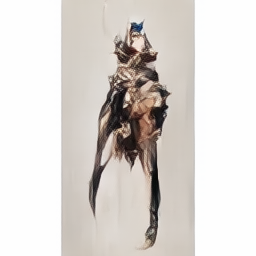
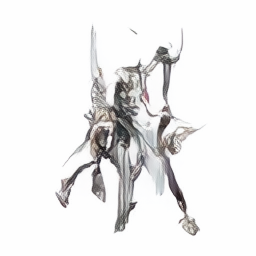
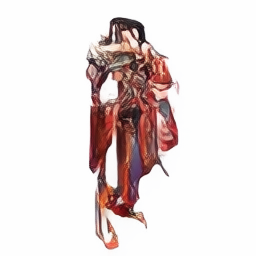


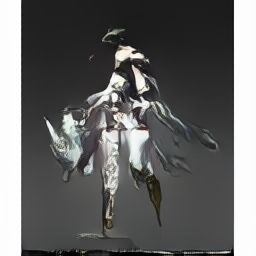
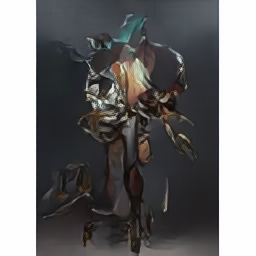
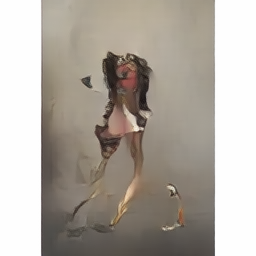

KeyboardInterrupt: 

In [ ]:
import IPython.display as ipd
import time

def show_some(model,labels, title="", output_file="outputs/tmp.html"):
    with torch.no_grad():
        device = next(model.parameters()).device
        model.to('cuda')
        imgs = model.generate(labels[0:3].cuda()).cpu()
        model.to(device)
        decoded =autoencoder.decode(autoencoder.post_quant(imgs))
        pils = [ih.tensor_to_pil(i) for i in decoded]
        h = f"<b>{title}</b>"
        h += ih.html_for_images(pils,title)
        if output_file:
            with open(output_file,"a") as f:
                f.write(h)
        ipd.display(ipd.HTML(h))

def train_some(model, dataloader, ema):
    restart_mlflow_run(mlflow,
        mlflow_experiment="fantasy",
        mlflow_run_name="LatentJiT",
        mlflow_run_id=None,
        loggable_params={'conf':'TODO: log_conf'}
    )
    best_loss = 1_000_000
    model_name = model.__class__.__name__
    model.train()
    t0 = time.time()
    counter = 0
    display_time_interval = 10
    next_display_time = time.time() + display_time_interval
    num_samples = len(dataloader.dataset)
    num_batches = len(dataloader)
    
    ema.get_model().config = {"TODO":"populate config"}
    ts = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    output_file = f"outputs/latent_jit_{ts}.html"
    checkpoint_path = f"checkpoints/{ts}_Latent_JiT_v1.pth"
    for epoch in range(100):
        for step, batch in enumerate(dataloader):
            id_batch,images,metadata_batch = batch
            labels = torch.zeros(images.shape[0], dtype=torch.long).cuda()
            images = images.cuda()
            labels = labels.cuda()
            optimizer.zero_grad()
            loss = model(images, labels)
            loss.backward()
            optimizer.step()
            counter += images.shape[0]
            ema.update(model)
            if time.time() > next_display_time:
                elapsed_time = time.time()-t0
                log_to_mlflow(mlflow,
                    elapsed_seconds=elapsed_time,
                    samples_processed = counter,
                    loss=loss,
                    sigma_bins = None,
                    sigma_bin_loss_ema = None,
                    samples_per_second = counter / elapsed_time,
                )
                ts = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
                model.config = {"TODO":"populate config"}
                metadata = {"TODO":"populate metadata"}
                if loss.item() < best_loss:
                    ch.save_checkpoint(checkpoint_path, model, optimizer, metadata)
                    ch.save_checkpoint(checkpoint_path + "_ema.pth", ema.get_model(), None, metadata)
                    best_loss = loss.item()
                status = f"{model_name} epoch {epoch}.{step*100//num_batches:02d}, rows {counter}, tm {elapsed_time}, loss {loss.item()}"
                ipd.clear_output(wait=True)
                model.eval()
                show_some(model,labels, status, output_file)
                show_some(ema.get_model(),labels, f"EMA {model_name} {counter}", output_file)
                model.train()
                display_time_interval = min(display_time_interval * 1.2,60*15)
                next_display_time = time.time() + display_time_interval
                
ema = eh.EDMEMAHelper(model, 
                step=1, batch_size=data_loader_train.batch_size, 
                ema_halflife_kimg=len(data_loader_train.dataset)/1000
                )
train_some(model,data_loader_train, ema)



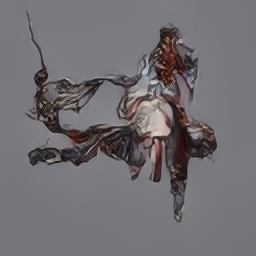
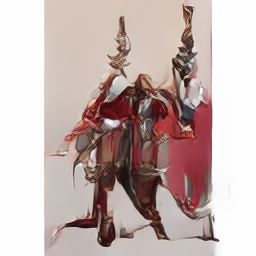
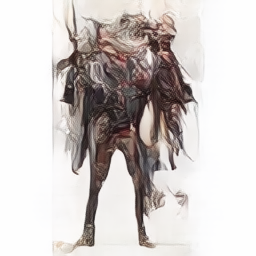


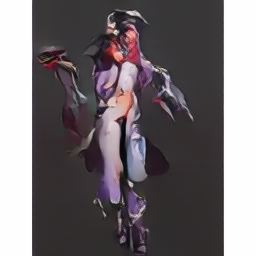
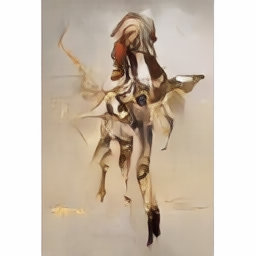
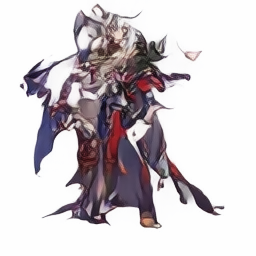

In [ ]:
model.eval()
labels = torch.zeros(3, dtype=torch.long).cuda()
show_some(model,labels, "hi", None)
show_some(ema.get_model(),labels, "hi", None)

In [ ]:
ts = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
model.config = {"TODO":"populate config"}
metadata = {"TODO":"populate metadata"}
checkpoint_path=f"checkpoints/{ts}_test4_28851_seconds.pth"
ch.save_checkpoint(checkpoint_path, model, optimizer, metadata)
ch.save_checkpoint(checkpoint_path + "_ema.pth", ema.get_model(), None, metadata)



warning, save_checkpoint args changed.  model comes first
✅ Saved checkpoint: checkpoints/2026-09-13_14-29-46_test4_28851_seconds.pth
warning, save_checkpoint args changed.  model comes first
✅ Saved checkpoint: checkpoints/2026-09-13_14-29-46_test4_28851_seconds.pth_ema.pth


'checkpoints/2026-09-13_14-29-46_test4_28851_seconds.pth_ema.pth'

In [ ]:
model

LatentDenoiser(
  (net): LatentJiT(
    (t_embedder): TimestepEmbedder(
      (mlp): Sequential(
        (0): Linear(in_features=256, out_features=384, bias=True)
        (1): SiLU()
        (2): Linear(in_features=384, out_features=384, bias=True)
      )
    )
    (y_embedder): LabelEmbedder(
      (embedding_table): Embedding(2, 384)
    )
    (x_embedder): Linear(in_features=16, out_features=384, bias=True)
    (feat_rope): VisionRotaryEmbeddingFast()
    (blocks): ModuleList(
      (0-5): 6 x JiTBlock(
        (norm1): RMSNorm()
        (attn): Attention(
          (q_norm): RMSNorm()
          (k_norm): RMSNorm()
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): RMSNorm()
        (mlp): SwiGLUFFN(
          (w12): Linear(in_features=384, out_features=2048, bi

In [ ]:
ch.create_from_checkpoint(LatentDenoiser,'checkpoints/2026-09-13_14-29-46_test4_28851_seconds.pth_ema.pth')

🔄 Loading checkpoint from checkpoints/2026-09-13_14-29-46_test4_28851_seconds.pth_ema.pth with {'TODO': 'populate config'}


TypeError: LatentDenoiser.__init__() got an unexpected keyword argument 'TODO'